In [12]:
# ============================== Block 1 ==============================
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt

import flopy
import flopy.utils as fu

from shutil import rmtree

# -------------------------------
# Matplotlib defaults
# -------------------------------
plt.rcParams["figure.dpi"] = 120

# -------------------------------
# Paths
# -------------------------------
root = Path.cwd().resolve().parents[1]   # notebooks/ -> Working/

workspace = root / "CS_A1" / "CrossSectionA_homo" / "CSA1_homo_no_bed"
workspace.mkdir(parents=True, exist_ok=True)

figs_path = workspace / "figures"
figs_path.mkdir(parents=True, exist_ok=True)

if workspace.name == "CS_A1":
    raise RuntimeError("Refusing to write directly into CS_A1 root.")

# -------------------------------
# Environment flags
# -------------------------------
def _get_env_bool(name: str, default: bool = True) -> bool:
    v = os.environ.get(name, str(default))
    return str(v).strip().lower() in {"1", "true", "t", "yes", "y", "on"}

write = _get_env_bool("WRITE", True)
run   = _get_env_bool("RUN", True)
plot  = _get_env_bool("PLOT", True)

# -------------------------------
# UNITS
# -------------------------------
length_units = "meters"
time_units   = "day"

# -------------------------------
# TIME (match realizations exactly)
# -------------------------------
TOTAL_YEARS    = 8000
INTERVAL_YEARS = 1000
nper   = TOTAL_YEARS // INTERVAL_YEARS              # 8
perlen = [365.0 * INTERVAL_YEARS] * nper            # days
nstp   = [2000] * nper                              # match realizations
tsmult = [1.0] * nper                               # match realizations

# -------------------------------
# GRID / MODEL (24 km × 300 m)
# -------------------------------
nlay = 30
nrow = 1
system_length = 24_000.0
ncol = 240                    # 100 m columns
delr = system_length / ncol
delc = 1.0
delv = 10.0
top  = 0.0
botm = [top - (k + 1) * delv for k in range(nlay)]  # -300 m

# -------------------------------
# SOLVER (robust for density coupling)
# -------------------------------
nouter, ninner = 800, 4000
hclose, rclose = 1e-4, 1e-2
relax          = 0.35

# -------------------------------
# Density / transport scalars
# -------------------------------
C0       = 0.0     # g/L (fresh)
Cmax     = 250.0   # g/L (brine)
buy_beta = 0.8     # kg/m^3 per g/L

# Dispersion / diffusion / porosity
alh = 30.0
ath1 = 5.0
atv = 0.20
diffusion_coefficient = 5.0e-9 * 86400.0  # m2/d
porosity_const = 0.30

# Hydraulic anisotropy
anisotropy_v = 5.0  # Kv = Kh/anisotropy_v

# Storage
Ss = 1e-4
Sy = 0.02

# -------------------------------
# Boundary scalars
# -------------------------------
inflow_top_thickness_m = 100.0
head_salar = -1.0
parameters = {"Scenario_A": {"inflow": 0.5}}  # m3/day per 1m thickness

# -------------------------------
# Homogeneous K (uniform everywhere)
# -------------------------------
K0_CONTINUOUS = 2.70052  # m/day (your geometric mean, excl bedrock)
K_homo = float(K0_CONTINUOUS)  # <- the uniform K you will run

# -------------------------------
# Scenario geometry (kept only for compatibility; NOT used for bedrock)
# -------------------------------
BEDROCK_START_M = 7_000.0
BEDROCK_END_M   = float(system_length)
BEDROCK_KILL_Z  = botm[-1] - 500.0

x_m_A  = [0.0, BEDROCK_START_M - 1.0, BEDROCK_START_M, 11_000.0, 14_000.0, 17_000.0, 20_000.0, BEDROCK_END_M]
zbed_A = [BEDROCK_KILL_Z, BEDROCK_KILL_Z, botm[-1], -210.0, -150.0, -115.0, -95.0, -85.0]

scenarios = {"Scenario_A": {"x": x_m_A, "z": zbed_A}}


In [13]:
# ============================== Block 2 ==============================
assert nrow == 1, "This workflow assumes a 2D cross-section (nrow == 1)."
assert len(botm) == nlay, "botm length must equal nlay."
assert np.isclose(delr * ncol, system_length), "Check system_length, delr, ncol consistency."

def summarize_config():
    print("[CONFIG]")
    print(f" workspace: {workspace}")
    print(f" nlay×nrow×ncol: {nlay} × {nrow} × {ncol}")
    print(f" delr, delc, delv: {delr}, {delc}, {delv}")
    print(f" system_length: {system_length}")
    print(f" time: nper={nper}, perlen[0]={perlen[0]}, nstp[0]={nstp[0]}, units={time_units}")
    print(f" density: C0={C0} g/L, Cmax={Cmax} g/L, beta={buy_beta} kg/m^3 per g/L")
    print(f" anisotropy_v: {anisotropy_v}, Ss={Ss}, Sy={Sy}")
    print(f" head_salar: {head_salar} m")
    print(f" homogeneous K_homo: {K_homo} m/d")
    print(f" solver: nouter={nouter}, ninner={ninner}, relax={relax}")
    print(f" env flags: write={write}, run={run}, plot={plot}")

summarize_config()


[CONFIG]
 workspace: C:\Jupyterbook\CS_A1\CrossSectionA_homo\CSA1_homo_no_bed
 nlay×nrow×ncol: 30 × 1 × 240
 delr, delc, delv: 100.0, 1.0, 10.0
 system_length: 24000.0
 time: nper=8, perlen[0]=365000.0, nstp[0]=2000, units=day
 density: C0=0.0 g/L, Cmax=250.0 g/L, beta=0.8 kg/m^3 per g/L
 anisotropy_v: 5.0, Ss=0.0001, Sy=0.02
 head_salar: -1.0 m
 homogeneous K_homo: 2.70052 m/d
 solver: nouter=800, ninner=4000, relax=0.35
 env flags: write=True, run=True, plot=True


In [14]:
# ============================== Block 2.5 (UPDATED) ==============================
import flopy
import numpy as np

def build_models_homo(sim_folder: str, *, inflow: float, K_uniform: float, geo: dict):
    """
    Fully homogeneous run:
      - K is uniform everywhere (no bedrock, no facies)
      - no bedrock masking logic anywhere
      - keeps your BCs + BUY coupling exactly as in your workflow
    """
    sim_ws = workspace / sim_folder
    sim_ws.mkdir(parents=True, exist_ok=True)

    sim = flopy.mf6.MFSimulation(
        sim_name=sim_folder,
        exe_name="mf6.exe",
        sim_ws=sim_ws,
    )

    # --- TDIS ---
    perioddata = [(float(perlen[i]), int(nstp[i]), float(tsmult[i])) for i in range(int(nper))]
    flopy.mf6.ModflowTdis(sim, time_units="DAYS", nper=int(nper), perioddata=perioddata)

    # --- IMS: flow + trans ---
    ims_flow = flopy.mf6.ModflowIms(
        sim, pname="IMS-FLOW", filename="flow.ims",
        print_option="SUMMARY", complexity="complex",
        outer_maximum=int(nouter), outer_dvclose=float(hclose),
        inner_maximum=int(ninner), inner_dvclose=float(hclose),
        rcloserecord=float(rclose), relaxation_factor=float(relax),
    )
    ims_trans = flopy.mf6.ModflowIms(
        sim, pname="IMS-TRANS", filename="trans.ims",
        print_option="SUMMARY", complexity="moderate",
        outer_maximum=int(nouter), outer_dvclose=float(hclose),
        inner_maximum=int(ninner), inner_dvclose=float(hclose),
        rcloserecord=float(rclose), relaxation_factor=float(relax),
    )

    # --- GWF ---
    gwf = flopy.mf6.ModflowGwf(sim, modelname="flow", save_flows=True, newtonoptions="NEWTON")
    sim.register_ims_package(ims_flow, [gwf.name])

    flopy.mf6.ModflowGwfdis(
        gwf, nlay=int(nlay), nrow=int(nrow), ncol=int(ncol),
        length_units="METERS", delr=delr, delc=delc, top=top, botm=botm
    )

    # uniform K field
    K3d = np.full((int(nlay), int(nrow), int(ncol)), float(K_uniform), dtype=float)
    k33 = (K3d / float(anisotropy_v))

    flopy.mf6.ModflowGwfnpf(
        gwf,
        save_specific_discharge=True,
        icelltype=0,
        k=K3d,
        k33=k33
    )

    steady = {0: False}
    transient = {kper: True for kper in range(int(nper))}
    flopy.mf6.ModflowGwfsto(
        gwf, iconvert=0, ss=float(Ss), sy=float(Sy),
        steady_state=steady, transient=transient, save_flows=True
    )

    flopy.mf6.ModflowGwfic(gwf, strt=float(head_salar))

    # --- GWT ---
    gwt = flopy.mf6.ModflowGwt(sim, modelname="trans", save_flows=True)
    sim.register_ims_package(ims_trans, [gwt.name])

    flopy.mf6.ModflowGwtdis(
        gwt, nlay=int(nlay), nrow=int(nrow), ncol=int(ncol),
        delr=delr, delc=delc, top=top, botm=botm
    )

    # ---- Initial concentration (brine pool), homogeneous domain ----
    C_ic = np.full((int(nlay), int(nrow), int(ncol)), float(C0), dtype=float)

    HALITE_X_MAX_M     = 9000.0
    HALITE_THICKNESS_M = 250.0

    j_cnc_max = min(int(HALITE_X_MAX_M / float(delr)), int(ncol) - 1)
    n_top_layers = min(int(HALITE_THICKNESS_M / float(delv)), int(nlay))

    brine_mask = np.zeros((int(nlay), 1, int(ncol)), dtype=bool)
    brine_mask[0:n_top_layers, 0, 0:j_cnc_max+1] = True

    # no bedrock exclusion here
    C_ic[brine_mask] = float(Cmax)
    flopy.mf6.ModflowGwtic(gwt, strt=C_ic)

    flopy.mf6.ModflowGwtmst(gwt, porosity=float(porosity_const))
    flopy.mf6.ModflowGwtadv(gwt, scheme="UPSTREAM")
    flopy.mf6.ModflowGwtdsp(
        gwt,
        alh=float(alh), ath1=float(ath1), atv=float(atv),
        diffc=float(diffusion_coefficient)
    )

    # --- FLOW BCs ---
    # (A) LEFT CHD full-depth at x=0
    chd_cells = [((k, 0, 0), float(head_salar)) for k in range(int(nlay))]
    chd_spd = {sp: chd_cells for sp in range(int(nper))}
    flopy.mf6.ModflowGwfchd(gwf, stress_period_data=chd_spd, pname="CHD-LEFT", save_flows=True)

    # (B) DRN evap zone – top layer x ~ 9.5–15 km
    j_evap_start = max(0, min(int(round(9500.0 / float(delr))), int(ncol) - 1))
    j_evap_end   = max(0, min(int(round(15000.0 / float(delr))), int(ncol) - 1))
    if j_evap_end < j_evap_start:
        j_evap_start, j_evap_end = j_evap_end, j_evap_start

    drn_cells = [((0, 0, j), float(top)) for j in range(j_evap_start, j_evap_end + 1)]
    if drn_cells:
        cond_per_cell = float(inflow) / float(len(drn_cells))
        drn_spd = {
            sp: [(cid, elev, cond_per_cell, float(C0)) for (cid, elev) in drn_cells]
            for sp in range(int(nper))
        }
        flopy.mf6.ModflowGwfdrn(
            gwf, stress_period_data=drn_spd, pname="DRN-EVAP",
            auxiliary=["CONCENTRATION"], save_flows=True
        )

    # (C) RIGHT WEL inflow – upper inflow_top_thickness_m
    j_right = int(ncol) - 1
    n_in_layers = max(1, min(int(inflow_top_thickness_m / float(delv)), int(nlay)))
    inflow_cells = [(k, 0, j_right) for k in range(n_in_layers)]

    q_per_cell = float(inflow) / float(len(inflow_cells))
    wel_spd = {sp: [[cell, q_per_cell, float(C0)] for cell in inflow_cells] for sp in range(int(nper))}
    flopy.mf6.ModflowGwfwel(
        gwf, stress_period_data=wel_spd, pname="WEL-RIGHT",
        auxiliary=["CONCENTRATION"], save_flows=True
    )

    # --- TRANSPORT BCs ---
    k_idx, _, j_idx = np.where(brine_mask)
    cnc_cells = [((int(k), 0, int(j)), float(Cmax)) for k, j in zip(k_idx, j_idx)]
    cnc_spd = {sp: cnc_cells for sp in range(int(nper))}
    flopy.mf6.ModflowGwtcnc(gwt, stress_period_data=cnc_spd, pname="CNC-BRINE", save_flows=True)

    flopy.mf6.ModflowGwtssm(
        gwt,
        sources=[
            ("WEL-RIGHT", "AUX", "CONCENTRATION"),
            ("DRN-EVAP",  "AUX", "CONCENTRATION"),
        ],
        save_flows=True
    )

    # --- BUY density coupling + exchange ---
    flopy.mf6.ModflowGwfbuy(
        gwf,
        nrhospecies=1,
        denseref=1000.0,
        packagedata=[(0, float(buy_beta), 0.0, gwt.name, "CONCENTRATION")],
    )
    flopy.mf6.ModflowGwfgwt(
        sim,
        exgtype="GWF6-GWT6",
        exgmnamea=gwf.name,
        exgmnameb=gwt.name,
        filename="flow.gwfgwt"
    )

    # --- Output control ---
    flopy.mf6.ModflowGwfoc(
        gwf,
        head_filerecord="flow.hds",
        budget_filerecord="flow.bud",
        saverecord=[("HEAD","LAST"),("BUDGET","LAST")],
        printrecord=[("HEAD","LAST"),("BUDGET","LAST")]
    )
    flopy.mf6.ModflowGwtoc(
        gwt,
        concentration_filerecord="trans.ucn",
        budget_filerecord="trans.cbc",
        saverecord=[("CONCENTRATION","LAST"),("BUDGET","LAST")],
        printrecord=[("CONCENTRATION","LAST"),("BUDGET","LAST")]
    )

    # attach K for plotting convenience (optional)
    gwf._K3d_homo = K3d

    return sim


In [15]:
# ============================== Block 4 ==============================
from pathlib import Path as _Path
import numpy as np
import matplotlib.pyplot as plt
import flopy.utils as fu

figure_size = (12, 5)

def _grid_coords(dis):
    delrA = dis.delr.array
    topA  = dis.top.array
    botmA = dis.botm.array
    nlayA = int(dis.nlay.data)
    x = np.cumsum(delrA) - 0.5 * delrA
    z_top = float(topA[0,0]); z_bot = float(botmA[-1,0,0])
    z = z_top - (np.arange(nlayA) + 0.5) * (z_top - z_bot) / nlayA
    return x, z, topA, botmA, delrA

def _read_last_array_safely(path, kind="head"):
    path = _Path(path)
    if not path.exists() or path.stat().st_size < 512:
        return None, None
    tries = []
    if kind == "head":
        tries = [(fu.HeadFile, {"precision":"double"}), (fu.HeadFile, {"precision":"single"})]
    elif kind == "ucn":
        tries = [(fu.UcnFile, {"precision":"double"}), (fu.UcnFile, {"precision":"single"}),
                 (fu.HeadFile, {"text":"CONCENTRATION","precision":"double"}),
                 (fu.HeadFile, {"text":"CONCENTRATION","precision":"single"})]
    last_err = None
    for cls, kw in tries:
        try:
            fh = cls(path.as_posix(), **kw)
            times = fh.get_times()
            if not times:
                continue
            arr = fh.get_data(totim=times[-1])
            return times, arr
        except Exception as e:
            last_err = e
    print(f"[read_safely] Failed {path.name}: {last_err}")
    return None, None

def _read_nearest_time_array(path, target_totim, kind="head"):
    path = _Path(path)
    if not path.exists() or path.stat().st_size < 512:
        return None, None
    tries = []
    if kind == "head":
        tries = [(fu.HeadFile, {"precision":"double"}), (fu.HeadFile, {"precision":"single"})]
    elif kind == "ucn":
        tries = [(fu.UcnFile, {"precision":"double"}), (fu.UcnFile, {"precision":"single"}),
                 (fu.HeadFile, {"text":"CONCENTRATION","precision":"double"}),
                 (fu.HeadFile, {"text":"CONCENTRATION","precision":"single"})]
    last_err = None
    for cls, kw in tries:
        try:
            fh = cls(path.as_posix(), **kw)
            times = fh.get_times()
            if not times:
                continue
            diffs = [abs(float(t) - float(target_totim)) for t in times]
            idx = int(np.argmin(diffs))
            totim = float(times[idx])
            arr = fh.get_data(totim=totim)
            return totim, arr
        except Exception as e:
            last_err = e
    print(f"[read_nearest] Failed {path.name}: {last_err}")
    return None, None

def plot_hydrostrat(sim, title="Hydrostrat (homogeneous)"):
    gwf = sim.get_model("flow"); dis = gwf.get_package("dis")
    x, _, topA, botmA, delrA = _grid_coords(dis)
    nlay_ = int(dis.nlay.data); ncol_ = int(dis.ncol.data)


In [16]:
# ============================== Block 4 ==============================
from pathlib import Path as _Path
import numpy as np
import matplotlib.pyplot as plt
import flopy.utils as fu

figure_size = (12, 5)

def _grid_coords(dis):
    delrA = dis.delr.array
    topA  = dis.top.array
    botmA = dis.botm.array
    nlayA = int(dis.nlay.data)
    x = np.cumsum(delrA) - 0.5 * delrA
    z_top = float(topA[0,0]); z_bot = float(botmA[-1,0,0])
    z = z_top - (np.arange(nlayA) + 0.5) * (z_top - z_bot) / nlayA
    return x, z, topA, botmA, delrA

def _read_last_array_safely(path, kind="head"):
    path = _Path(path)
    if not path.exists() or path.stat().st_size < 512:
        return None, None
    tries = []
    if kind == "head":
        tries = [(fu.HeadFile, {"precision":"double"}), (fu.HeadFile, {"precision":"single"})]
    elif kind == "ucn":
        tries = [(fu.UcnFile, {"precision":"double"}), (fu.UcnFile, {"precision":"single"}),
                 (fu.HeadFile, {"text":"CONCENTRATION","precision":"double"}),
                 (fu.HeadFile, {"text":"CONCENTRATION","precision":"single"})]
    last_err = None
    for cls, kw in tries:
        try:
            fh = cls(path.as_posix(), **kw)
            times = fh.get_times()
            if not times:
                continue
            arr = fh.get_data(totim=times[-1])
            return times, arr
        except Exception as e:
            last_err = e
    print(f"[read_safely] Failed {path.name}: {last_err}")
    return None, None

def _read_nearest_time_array(path, target_totim, kind="head"):
    path = _Path(path)
    if not path.exists() or path.stat().st_size < 512:
        return None, None
    tries = []
    if kind == "head":
        tries = [(fu.HeadFile, {"precision":"double"}), (fu.HeadFile, {"precision":"single"})]
    elif kind == "ucn":
        tries = [(fu.UcnFile, {"precision":"double"}), (fu.UcnFile, {"precision":"single"}),
                 (fu.HeadFile, {"text":"CONCENTRATION","precision":"double"}),
                 (fu.HeadFile, {"text":"CONCENTRATION","precision":"single"})]
    last_err = None
    for cls, kw in tries:
        try:
            fh = cls(path.as_posix(), **kw)
            times = fh.get_times()
            if not times:
                continue
            diffs = [abs(float(t) - float(target_totim)) for t in times]
            idx = int(np.argmin(diffs))
            totim = float(times[idx])
            arr = fh.get_data(totim=totim)
            return totim, arr
        except Exception as e:
            last_err = e
    print(f"[read_nearest] Failed {path.name}: {last_err}")
    return None, None

def plot_hydrostrat(sim, title="Hydrostrat (homogeneous)"):
    gwf = sim.get_model("flow"); dis = gwf.get_package("dis")
    x, _, topA, botmA, delrA = _grid_coords(dis)
    nlay_ = int(dis.nlay.data); ncol_ = int(dis.ncol.data)

    layer_tops = np.vstack([topA, botmA[:-1,0,:]])
    layer_bots = botmA[:,0,:]

    fig, ax = plt.subplots(figsize=figure_size)
    for k in range(nlay_):
        ytop, ybot = layer_tops[k,:], layer_bots[k,:]
        for j in range(ncol_):
            ax.fill_between([x[j]-0.5*delrA[j], x[j]+0.5*delrA[j]],
                            [ybot[j], ybot[j]], [ytop[j], ytop[j]],
                            color="#cfcfcf", edgecolor="k", linewidth=0.15)

    ax.set_xlabel("Horizontal Distance (m)")
    ax.set_ylabel("Elevation (m)")
    ax.set_title(title)
    ax.set_ylim(float(botmA[-1,0,0]), float(topA[0,0]))
    plt.tight_layout(); plt.show()

def plot_heads(sim, title="Head (last)"):
    gwf = sim.get_model("flow"); dis = gwf.get_package("dis")
    x, z, *_ = _grid_coords(dis)
    _, H3d = _read_last_array_safely(_Path(gwf.model_ws)/"flow.hds", kind="head")
    if H3d is None:
        return
    H = H3d[:,0,:].astype(float)
    X, Z = np.meshgrid(x, z)

    fig, ax = plt.subplots(figsize=figure_size)
    cs = ax.contourf(X, Z, H, levels=40, cmap="viridis")
    plt.colorbar(cs, ax=ax, label="Head (m)")
    ax.set_xlabel("Horizontal Distance (m)")
    ax.set_ylabel("Elevation (m)")
    ax.set_ylim(float(dis.botm.array[-1,0,0]), float(dis.top.array[0,0]))
    ax.set_title(title)
    plt.tight_layout(); plt.show()

def plot_salinity_at(sim, years, title_prefix="Salinity"):
    gwt = sim.get_model("trans")
    if gwt is None:
        return
    dis = gwt.get_package("dis")
    x, z, *_ = _grid_coords(dis)
    totim = float(years) * 365.0

    t_used, C3d = _read_nearest_time_array(_Path(gwt.model_ws)/"trans.ucn", totim, kind="ucn")
    if C3d is None:
        print(f"[salinity_at] no data near {years} yr")
        return

    C = C3d[:,0,:]
    X, Z = np.meshgrid(x, z)

    fig, ax = plt.subplots(figsize=figure_size)
    levels = np.linspace(0.0, float(Cmax), 41)
    cs = ax.contourf(X, Z, C, levels=levels, cmap="viridis")
    plt.colorbar(cs, ax=ax, label="Concentration (g/L)")
    ax.set_xlabel("Horizontal Distance (m)")
    ax.set_ylabel("Elevation (m)")
    ax.set_ylim(float(dis.botm.array[-1,0,0]), float(dis.top.array[0,0]))
    ax.set_title(f"{title_prefix} (t≈{t_used/365:.1f} yr)")
    plt.tight_layout(); plt.show()

def plot_quiver_at(sim, years, every=3, title_prefix="Head + Specific discharge"):
    gwf = sim.get_model("flow")
    if gwf is None:
        return
    dis = gwf.get_package("dis")
    x, z, *_ = _grid_coords(dis)
    totim = float(years) * 365.0

    t_used, H3d = _read_nearest_time_array(_Path(gwf.model_ws)/"flow.hds", totim, kind="head")
    if H3d is None:
        print(f"[quiver_at] no head near {years} yr")
        return
    H = H3d[:,0,:]

    qx = qz = None
    bud_path = _Path(gwf.model_ws)/"flow.bud"
    if bud_path.exists():
        try:
            cbb = fu.CellBudgetFile(bud_path.as_posix(), precision="double")
            sp = cbb.get_data(text="DATA-SPDIS", totim=t_used)
            if sp:
                rec = sp[0]
                qx = rec["qx"].reshape((int(dis.nlay.data),1,int(dis.ncol.data)))[:,0,:]
                qz = rec["qz"].reshape((int(dis.nlay.data),1,int(dis.ncol.data)))[:,0,:]
        except Exception as e:
            print(f"[quiver_at] budget read failed: {e}")

    X, Z = np.meshgrid(x, z)
    fig, ax = plt.subplots(figsize=figure_size)
    cs = ax.contourf(X, Z, H, levels=40, cmap="viridis")
    plt.colorbar(cs, ax=ax, label="Head (m)")

    if qx is not None and qz is not None:
        ds = (slice(None, None, every), slice(None, None, every))
        spd = np.hypot(qx, qz)
        U = qx / (spd + 1e-12)
        V = -qz / (spd + 1e-12)
        Q = ax.quiver(X[ds], Z[ds], U[ds], V[ds], spd[ds], cmap="magma", pivot="mid", scale=25)
        plt.colorbar(Q, ax=ax, label="|q| (model units)")

    ax.set_xlabel("Horizontal Distance (m)")
    ax.set_ylabel("Elevation (m)")
    ax.set_ylim(float(dis.botm.array[-1,0,0]), float(dis.top.array[0,0]))
    ax.set_title(f"{title_prefix} (t≈{t_used/365:.1f} yr)")
    plt.tight_layout(); plt.show()



=== Running Scenario_A_homo_no_bed (HOMOGENEOUS K, NO BEDROCK) ===
Workspace: C:\Jupyterbook\CS_A1\CrossSectionA_homo\CSA1_homo_no_bed
FloPy is using the following executable to run the model: ..\..\..\..\..\EXE\mf6.exe
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.5.0 05/23/2024

   MODFLOW 6 compiled May 23 2024 18:06:57 with Intel(R) Fortran Intel(R) 64
   Compiler Classic for applications running on Intel(R) 64, Version 2021.7.0
                             Build 20220726_000000

This software has been approved for release by the U.S. Geological 
Survey (USGS). Although the software has been subjected to rigorous 
review, the USGS reserves the right to update the software as needed 
pursuant to further analysis and review. No warranty, expressed or 
implied, is made by the USGS or the U.S. Government as to the 
functionality of the software and related material nor shall the 
fact 

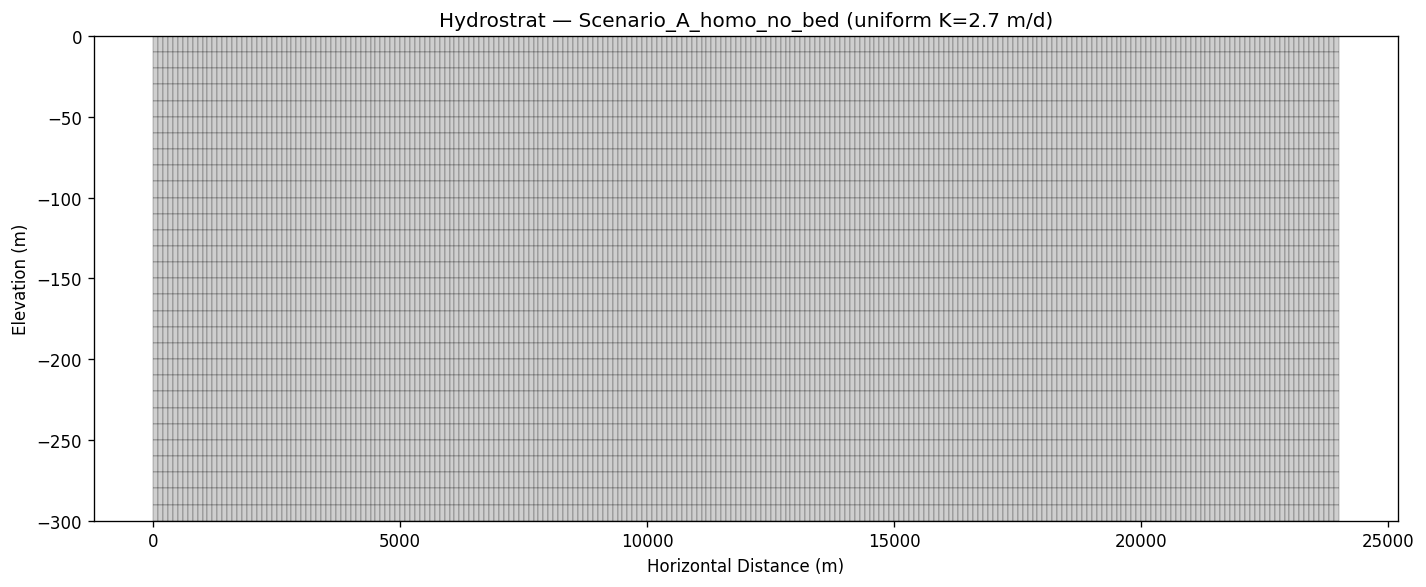

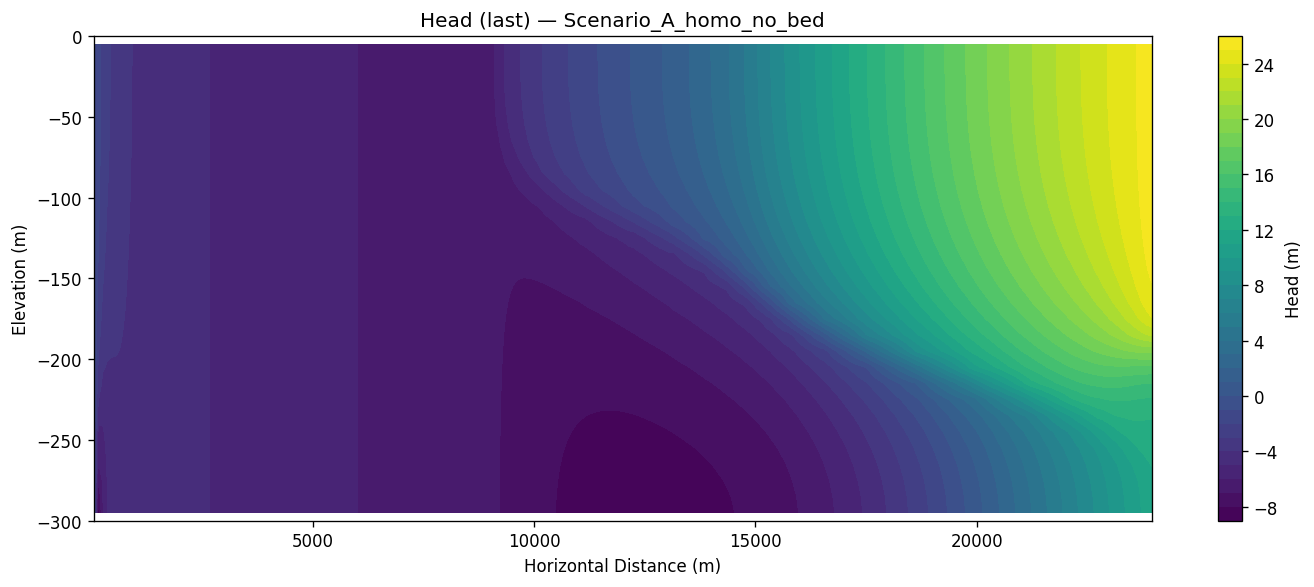

C:\Users\isabe\AppData\Local\Programs\Python\Python312\Lib\site-packages\flopy\utils\binaryfile.py:484: UserWarning: Very large grid, ncol (538976334) * nrow (240) > 10000000
  warnings.warn(


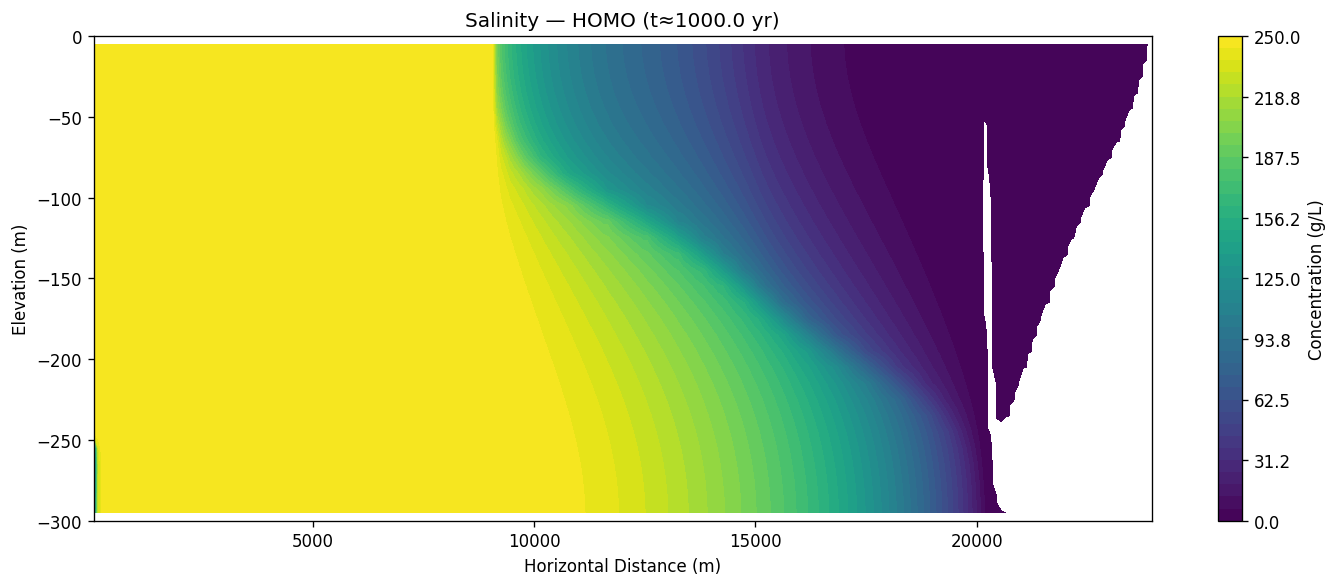

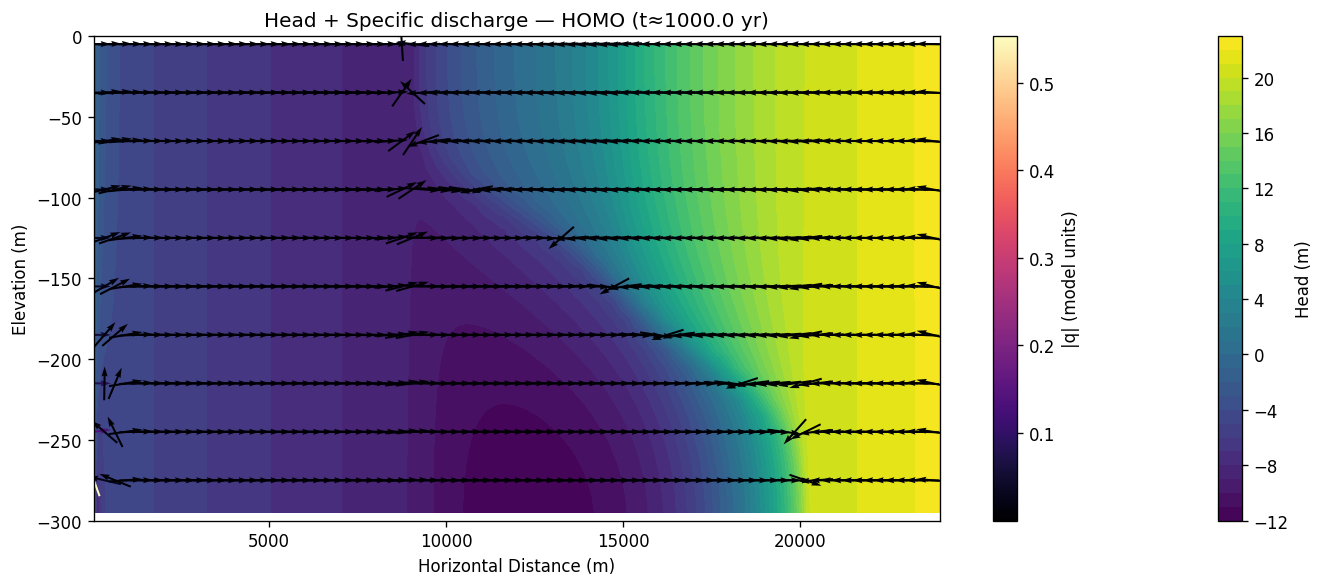

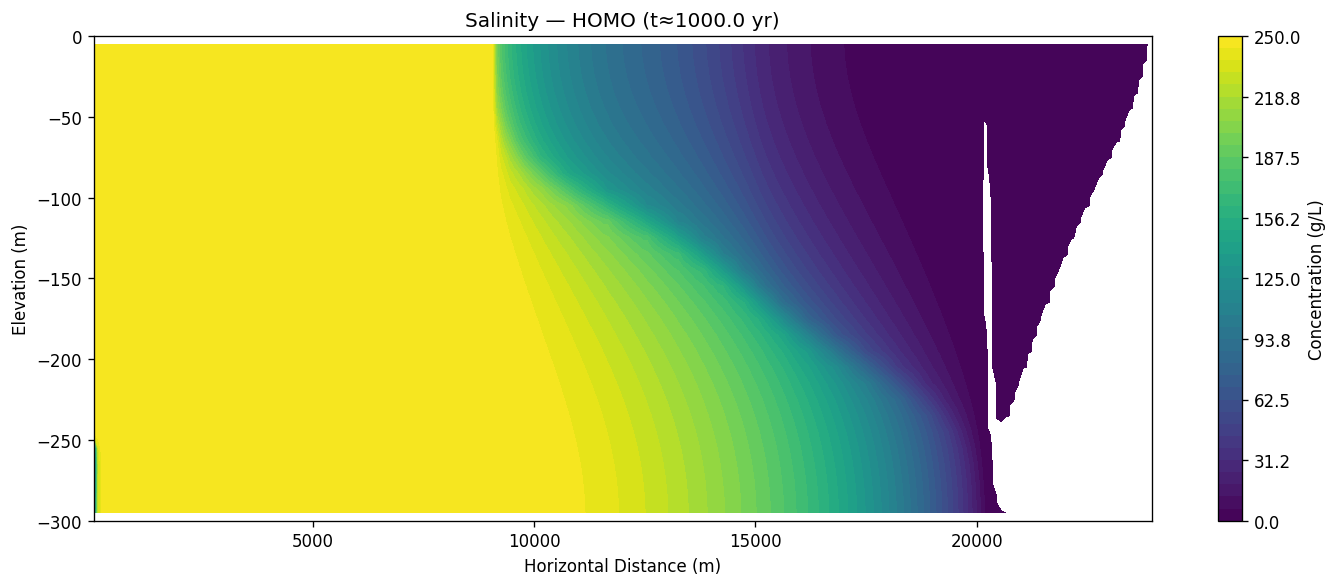

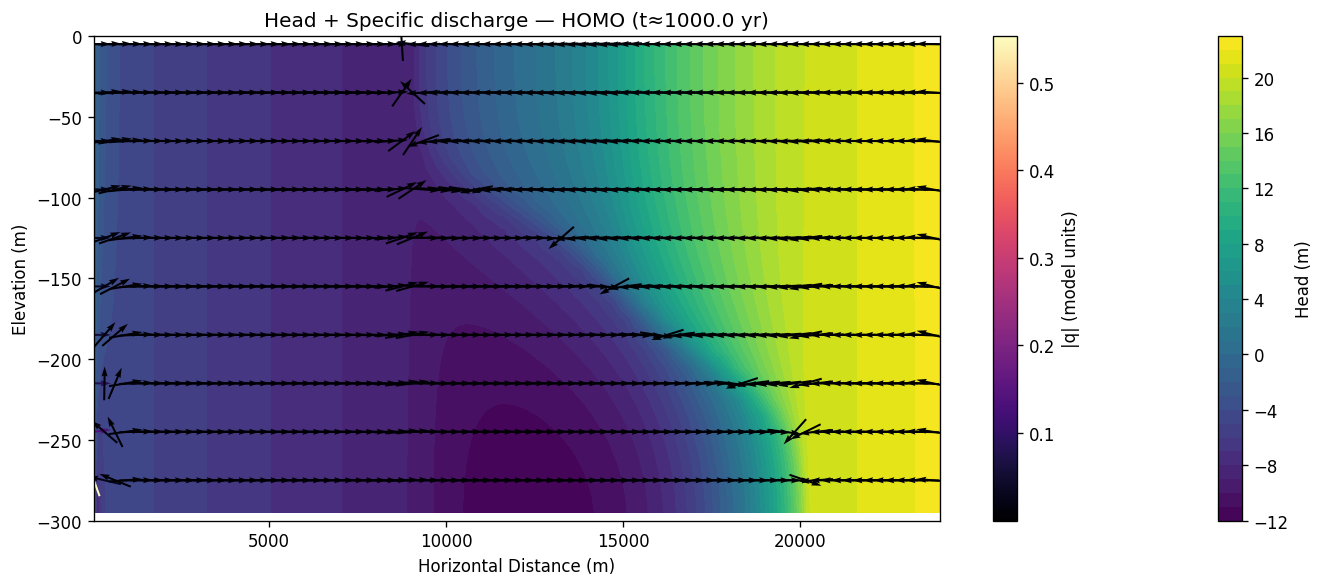

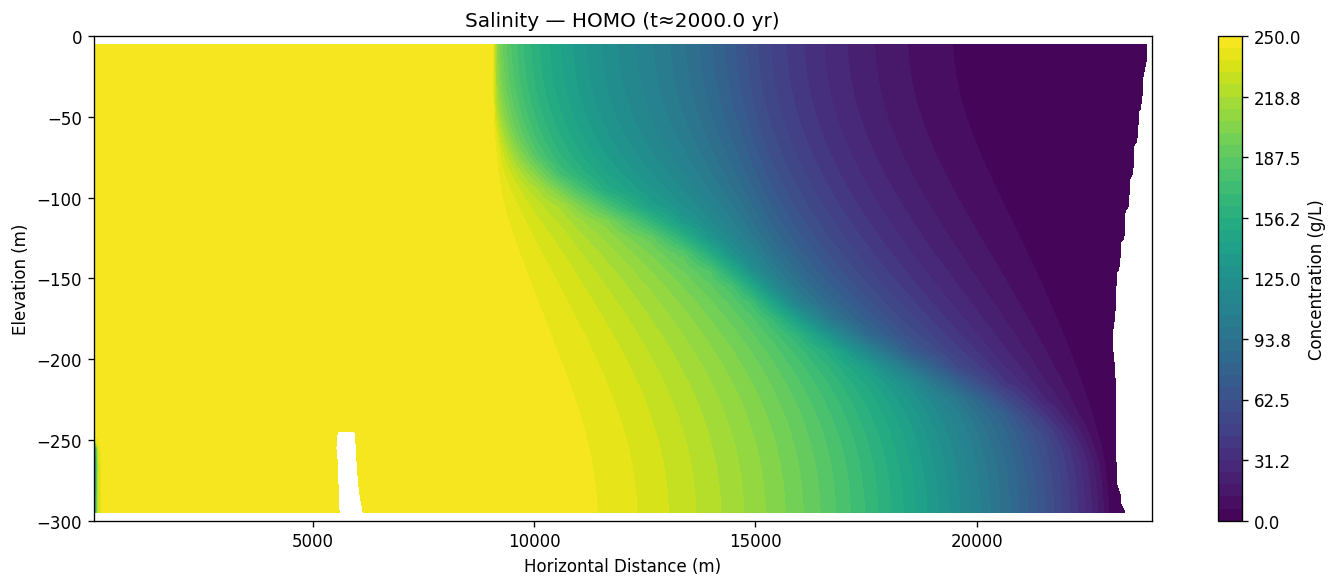

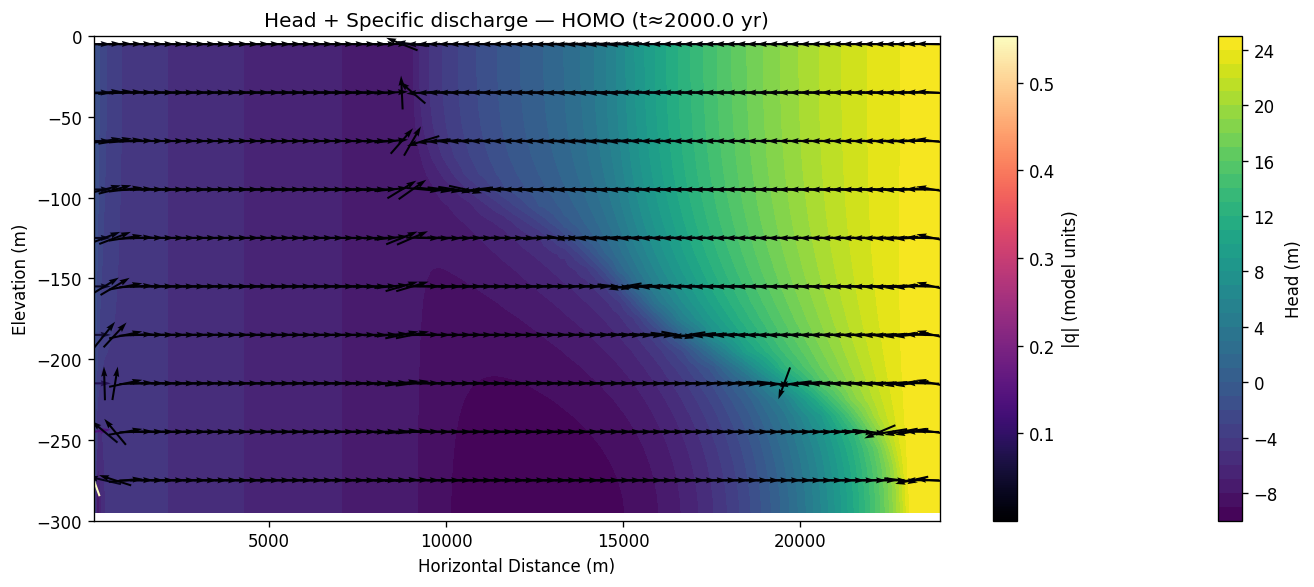

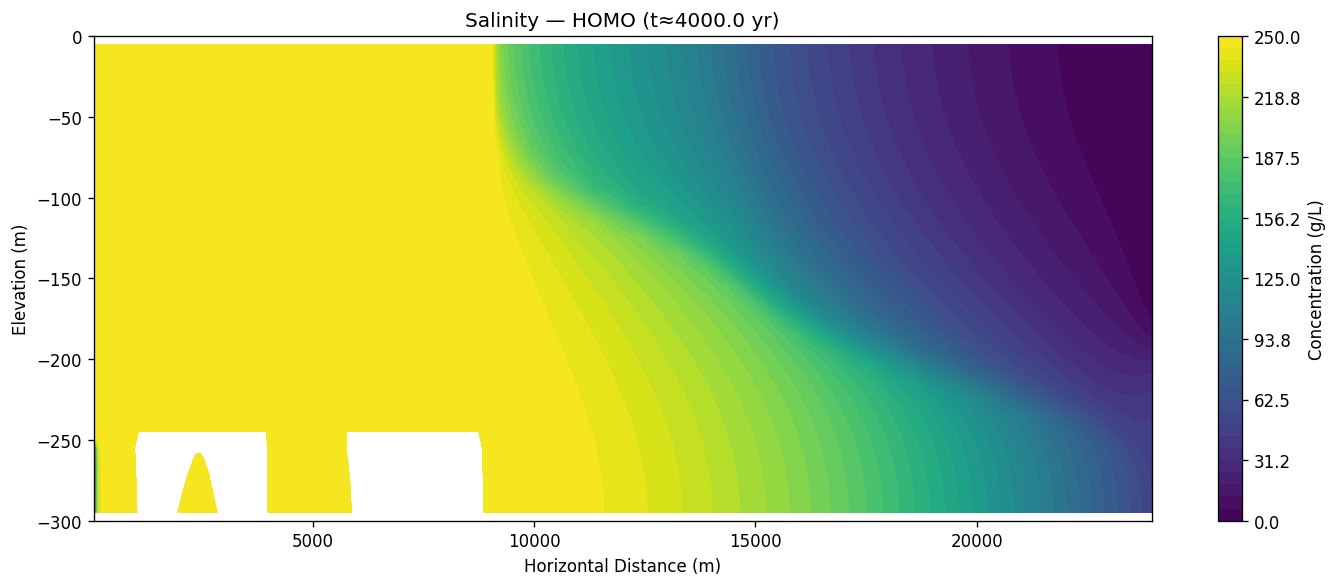

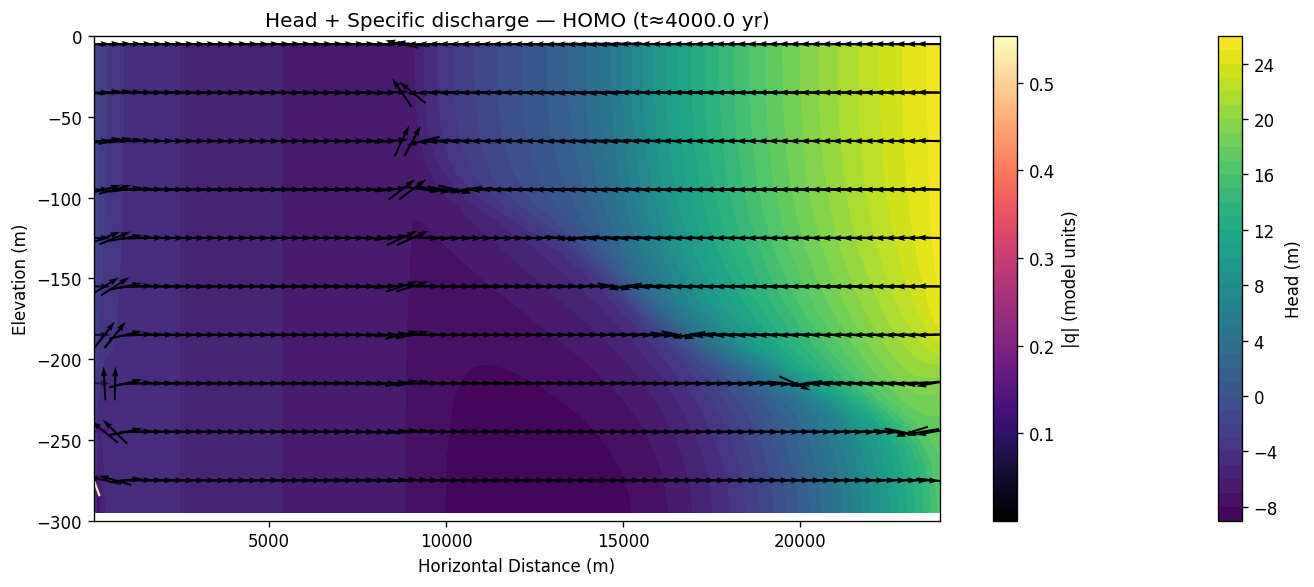

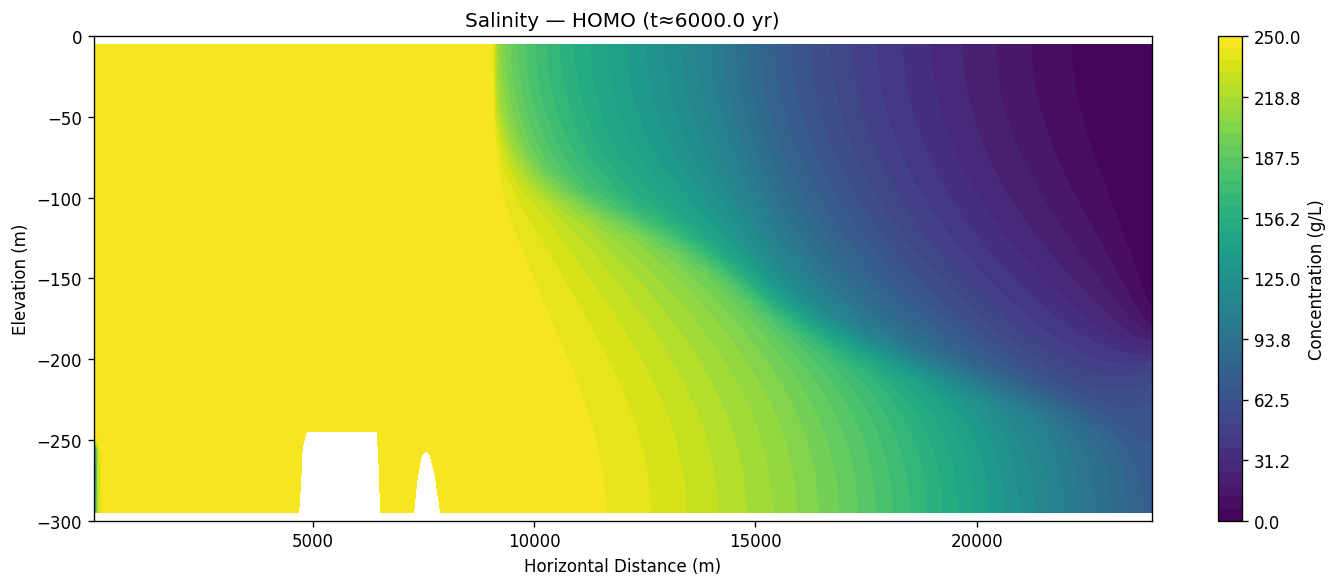

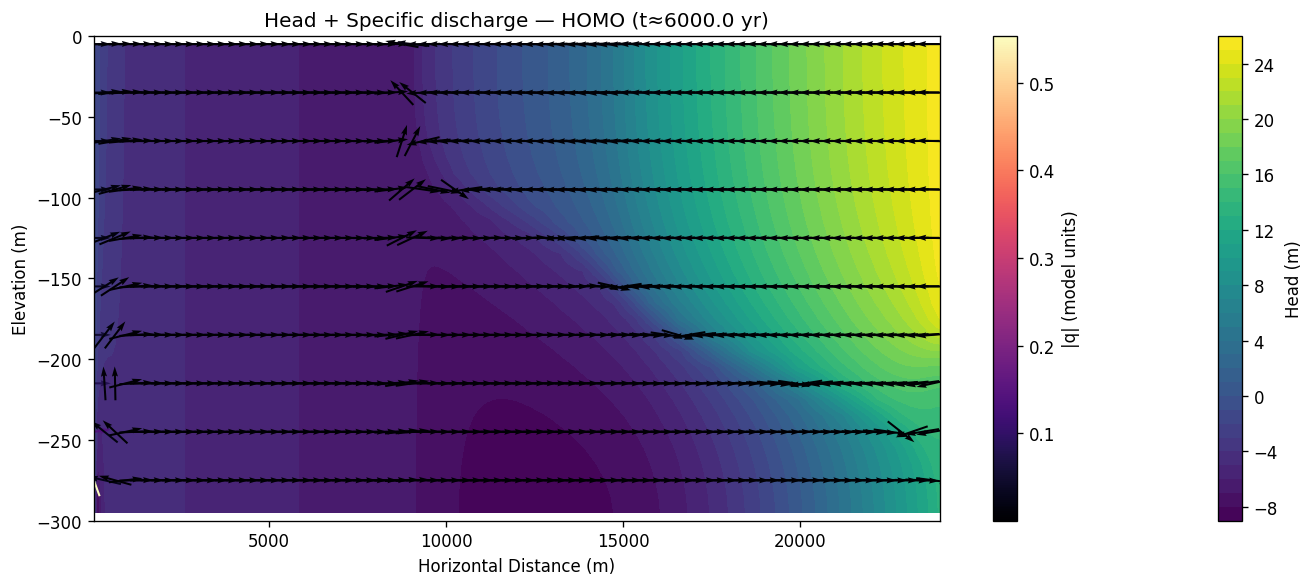

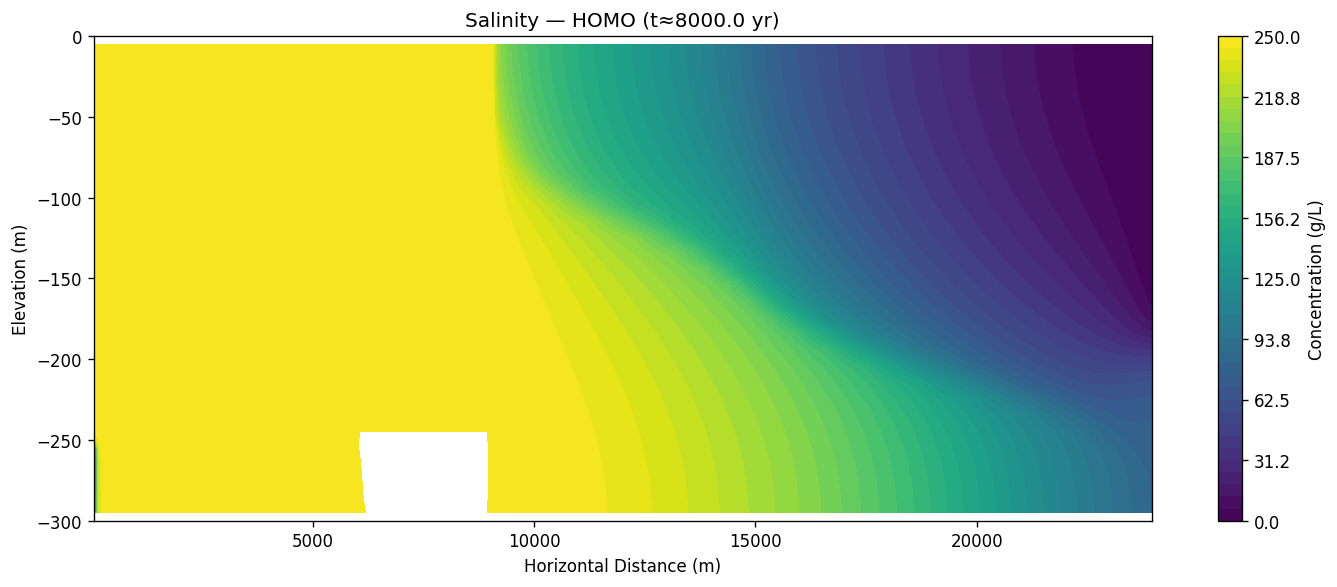

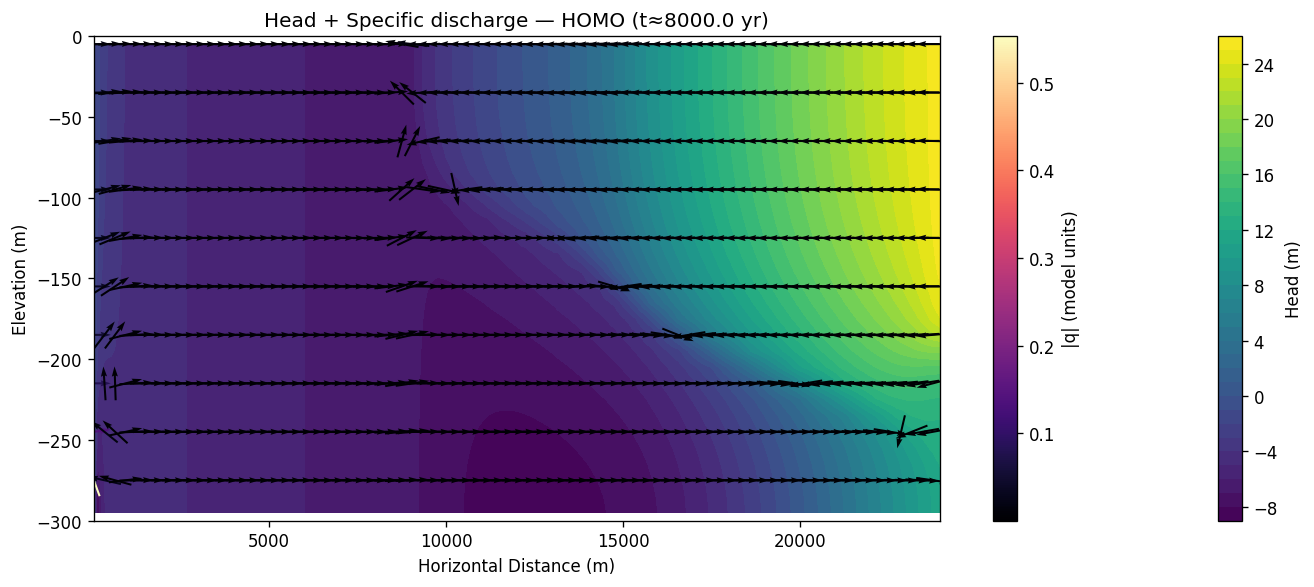

In [17]:
# ============================== Block 5 ==============================
# --- run settings for homogeneous control ---
run_name     = "Scenario_A_homo_no_bed"
scenario_key = "Scenario_A"

geo        = scenarios[scenario_key]   # kept for compatibility
inflow_val = 0.5  # m³/d, to match the hetero run

print(f"\n=== Running {run_name} (HOMOGENEOUS K, NO BEDROCK) ===")
print("Workspace:", workspace)

# --- clean previous run directory ---
run_dir = workspace / run_name
rmtree(run_dir, ignore_errors=True)

# --- build homogeneous model ---
sim_h = build_models_homo(
    run_name,
    inflow=inflow_val,
    K_uniform=K_homo,
    geo=geo,
)

# --- write + run ---
if write:
    sim_h.write_simulation(silent=True)

ok, _ = sim_h.run_simulation(silent=False) if run else (True, None)
if not ok:
    raise RuntimeError("MODFLOW 6 failed for homogeneous control.")

# --- plots ---
SNAPSHOT_YEARS = [500, 1000, 2000, 4000, 6000, 8000]

if plot:
    try:
        plot_hydrostrat(sim_h, title=f"Hydrostrat — {run_name} (uniform K={K_homo:.3g} m/d)")
    except Exception as e:
        print(f"[plot] hydrostrat failed: {e}")

    try:
        plot_heads(sim_h, title=f"Head (last) — {run_name}")
    except Exception as e:
        print(f"[plot] heads failed: {e}")

    for yrs in SNAPSHOT_YEARS:
        try:
            plot_salinity_at(sim_h, yrs, title_prefix="Salinity — HOMO")
        except Exception as e:
            print(f"[plot] salinity {yrs} yr failed: {e}")
        try:
            plot_quiver_at(sim_h, yrs, every=3, title_prefix="Head + Specific discharge — HOMO")
        except Exception as e:
            print(f"[plot] quiver {yrs} yr failed: {e}")


In [6]:
# ============================== Block 6 (diagnostics + Excel export) — HOMO ==============================
from pathlib import Path as _Path
import numpy as np
import pandas as pd
import flopy.utils as fu

# ---------- Safe helpers ----------
def _decode_name(n):
    return n.decode("utf-8", "ignore").strip() if isinstance(n, (bytes, bytearray)) else str(n).strip()

def _nearest_time(times, target):
    times = [float(t) for t in times]
    idx = int(np.argmin([abs(t - target) for t in times]))
    return float(times[idx])

def _open_ucn_with_fallback(path):
    """Return (handler, times) or (None, None)."""
    tries = [
        (fu.UcnFile, {"precision": "double"}),
        (fu.UcnFile, {"precision": "single"}),
        (fu.HeadFile, {"text": "CONCENTRATION", "precision": "double"}),
        (fu.HeadFile, {"text": "CONCENTRATION", "precision": "single"}),
    ]
    for cls, kw in tries:
        try:
            fh = cls(path.as_posix(), **kw)
            ts = fh.get_times()
            if ts:
                return fh, ts
        except Exception:
            continue
    print("[debug ucn] could not read times with any handler")
    return None, None

def _read_conc_at_nearest(sim, target_totim):
    """Return (totim_used, C) with C shape (nlay, ncol), or (None, None)."""
    gwt = sim.get_model("trans")
    if gwt is None:
        return None, None
    p = _Path(gwt.model_ws) / "trans.ucn"
    if not p.exists() or p.stat().st_size < 512:
        return None, None
    fh, times = _open_ucn_with_fallback(p)
    if fh is None:
        return None, None
    t_use = _nearest_time(times, float(target_totim))
    try:
        arr = fh.get_data(totim=t_use)  # (nlay, nrow, ncol)
        C = np.asarray(arr, float)[:, 0, :]  # -> (nlay, ncol)
        return t_use, C
    except Exception:
        return None, None

def _spdis_center(sim, totim):
    """Return (qx_center, qz_center) at totim in cell centers [m/d], or (None, None)."""
    gwf = sim.get_model("flow")
    dis = gwf.get_package("dis")
    nlay = int(dis.nlay.data); ncol = int(dis.ncol.data)
    cbb_path = _Path(gwf.model_ws) / "flow.bud"
    if not cbb_path.exists():
        return None, None
    cbb = fu.CellBudgetFile(cbb_path.as_posix(), precision="double")
    try:
        sp = cbb.get_data(text="DATA-SPDIS", totim=totim)
        if sp:
            rec = sp[0]
            qx = rec["qx"].reshape((nlay, 1, ncol))[:, 0, :]
            qz = rec["qz"].reshape((nlay, 1, ncol))[:, 0, :]
            return qx, qz
    except Exception:
        pass
    # fallback to faces
    try:
        qxr = cbb.get_data(text="FLOW RIGHT FACE", totim=totim)[0][:, 0, :]   # (nlay, ncol+1)
        qzl = cbb.get_data(text="FLOW LOWER FACE", totim=totim)[0][:, 0, :]   # (nlay+1, ncol)
        qx = 0.5 * (qxr[:, :-1] + qxr[:, 1:])
        qz = 0.5 * (qzl[:-1, :] + qzl[1:, :])
        return qx, qz
    except Exception:
        return None, None

def _nearest_head_time(sim, target_totim):
    gwf = sim.get_model("flow")
    p = _Path(gwf.model_ws) / "flow.hds"
    if not p.exists() or p.stat().st_size < 512:
        return None
    for cls, kw in [(fu.HeadFile, {"precision": "double"}), (fu.HeadFile, {"precision": "single"})]:
        try:
            fh = cls(p.as_posix(), **kw)
            times = fh.get_times()
            if times:
                return _nearest_time(times, float(target_totim))
        except Exception:
            continue
    return None

# ---------- Diagnostics ----------
def _facies_flow_summary(sim, totim):
    """Average |q| by facies. In HOMO, this will typically report one facies (sediments_bg)."""
    gwf = sim.get_model("flow")
    dis = gwf.get_package("dis")
    karr = gwf.npf.k.array[:, 0, :]
    cat2d = getattr(gwf, "_facies_cat", None)
    if cat2d is None:
        # fallback: treat very low K as 'bedrock', everything else as 'sediments_bg'
        thresh = max(np.nanmax(karr) * 1e-6, 1e-9)
        cat2d = np.where(karr <= thresh, "bedrock", "sediments_bg")
    else:
        cat2d = cat2d[:, 0, :]

    qx, qz = _spdis_center(sim, totim)
    if qx is None or qz is None:
        return {}
    spd = np.hypot(qx, qz)
    report = {}
    for f in np.unique(cat2d.astype(str)):
        mask = (cat2d == f)
        n = int(np.sum(mask))
        if n > 0:
            report[f] = (float(np.nanmean(spd[mask])), n)
    return report

def _water_budget(sim, totim):
    """Return dict of {name: sum(m3/d)} using 'q' component only (no recarray summation)."""
    gwf = sim.get_model("flow")
    cbb_path = _Path(gwf.model_ws) / "flow.bud"
    if not cbb_path.exists():
        return {}
    cbb = fu.CellBudgetFile(cbb_path.as_posix(), precision="double")
    out = {}
    for raw in cbb.get_unique_record_names():
        name = _decode_name(raw)
        try:
            recs = cbb.get_data(text=raw, totim=totim)
        except Exception:
            try:
                recs = cbb.get_data(text=name, totim=totim)
            except Exception:
                recs = None
        if not recs:
            continue
        arr = recs[0]
        if hasattr(arr, "dtype") and arr.dtype.names and "q" in arr.dtype.names:
            val = float(np.nansum(arr["q"]))
        else:
            val = float(np.nansum(arr))
        out[name] = out.get(name, 0.0) + val
    return out

def _package_flux_table(sim, totim, keep=("WEL", "GHB")):
    bud = _water_budget(sim, totim)
    rows = []
    for k, v in bud.items():
        k2 = k.upper()
        if any(k2.startswith(tag) for tag in keep):
            rows.append({"totim_d": totim, "package": k2, "q_m3_d": v})
    return pd.DataFrame(rows).sort_values(["package"]).reset_index(drop=True)

def _interface_by_column(sim, totim, cutoff_gL=100.0):
    """Return DataFrame with interface depth per column (positive downward)."""
    gwt = sim.get_model("trans")
    if gwt is None:
        return pd.DataFrame()
    dis = gwt.get_package("dis")
    nlay, ncol = int(dis.nlay.data), int(dis.ncol.data)
    topA = float(dis.top.array[0, 0])
    botmA = float(dis.botm.array[-1, 0, 0])

    t_used, C = _read_conc_at_nearest(sim, totim)
    if C is None:
        return pd.DataFrame()

    depths = np.full(ncol, np.nan)
    for j in range(ncol):
        hits = np.where(C[:, j] >= float(cutoff_gL))[0]
        if hits.size > 0:
            k = int(hits[0])
            zc = topA - (k + 0.5) * (topA - botmA) / nlay
            depths[j] = -zc  # +down
    return pd.DataFrame({"col": np.arange(ncol, dtype=int), "depth_m_pos_down": depths})

def _conc_column_means(sim, totim):
    """Return per-column mean concentration (g/L)."""
    t_used, C = _read_conc_at_nearest(sim, totim)
    if C is None:
        return pd.DataFrame()
    means = np.nanmean(C, axis=0)  # (ncol,)
    return pd.DataFrame({"col": np.arange(C.shape[1], dtype=int), "C_mean_gL": means})

def _salt_budget(sim, totim):
    """
    Return dict with aquifer salt mass (kg) at totim.
    Uses porosity * cell volume * concentration; assumes 1 g/L ≈ 1 kg/m3 for density slope.
    """
    gwf = sim.get_model("flow")
    gwt = sim.get_model("trans")
    if gwf is None or gwt is None:
        return {}

    dis = gwf.get_package("dis")
    delr = np.asarray(dis.delr.array, float)
    delc = float(dis.delc.array) if np.ndim(dis.delc.array) == 0 else float(dis.delc.array[0])
    topA = float(dis.top.array[0, 0])
    botmA = float(dis.botm.array[-1, 0, 0])
    nlay, ncol = int(dis.nlay.data), int(dis.ncol.data)
    dz = (topA - botmA) / nlay

    t_used, C = _read_conc_at_nearest(sim, totim)
    if C is None:
        return {}

    vol = np.outer(np.ones(nlay)*dz, delr) * delc  # m3 (unit width)
    theta = float(globals().get("porosity_const", 0.30))
    salt_mass_kg = float(np.nansum(C * theta * vol))
    return {"totim_d": totim, "aquifer_salt_mass_kg": salt_mass_kg}

def _salt_flow_budget(sim, totim):
    """
    Return dict {term: kg/d} from trans.cbc at totim (mass rates by GWT budget term),
    summing the 'q' field for each record.
    """
    gwt = sim.get_model("trans")
    if gwt is None:
        return {}
    cbb_path = _Path(gwt.model_ws) / "trans.cbc"
    if not cbb_path.exists():
        return {}
    cbb = fu.CellBudgetFile(cbb_path.as_posix(), precision="double")
    out = {}
    for raw in cbb.get_unique_record_names():
        name = _decode_name(raw)  # e.g., MASS STORAGE, MASS SOURCES-SINKS
        try:
            recs = cbb.get_data(text=raw, totim=totim)
        except Exception:
            try:
                recs = cbb.get_data(text=name, totim=totim)
            except Exception:
                recs = None
        if not recs:
            continue
        arr = recs[0]
        if hasattr(arr, "dtype") and arr.dtype.names and "q" in arr.dtype.names:
            val = float(np.nansum(arr["q"]))
        else:
            val = float(np.nansum(arr))
        out[name] = out.get(name, 0.0) + val
    return out

def run_diagnostics(sim, years_list=(500, 1000, 2000, 4000, 6000, 8000), cutoff_gL=100.0):
    """Console diagnostics."""
    gwf = sim.get_model("flow")
    for yrs in years_list:
        target = float(yrs) * 365.0
        t_use = _nearest_head_time(sim, target)
        if t_use is None:
            print(f"\n[diagnostics] No data available near {yrs} years.")
            continue
        print("\n" + "=" * 72)
        print(f"DIAGNOSTICS @ t ≈ {t_use/365.0:.2f} years")
        print("=" * 72)
        facies = _facies_flow_summary(sim, t_use)
        if facies:
            print("\n=== FACIES FLOW SUMMARY (avg |q|, m/d) ===")
            for f in sorted(facies.keys()):
                av, n = facies[f]
                print(f"  {f:16s}  avg|q| = {av:10.4e}   (cells: {n})")
        bud = _water_budget(sim, t_use)
        if bud:
            print("\n=== WATER BUDGET at t ≈ {:.2f} yr (m3/d) ===".format(t_use/365.0))
            for k in sorted(bud.keys()):
                print(f"  {k:<24} {bud[k]:12.4f}")
            total_in  = sum(v for v in bud.values() if v > 0)
            total_out = sum(v for v in bud.values() if v < 0)
            print(f"  {'TOTAL IN':<24} {total_in:12.4f}")
            print(f"  {'TOTAL OUT':<24} {total_out:12.4f}")
            print(f"  {'IMBALANCE (IN+OUT)':<24} {total_in + total_out:12.6f}")

# ---------- Excel export (snapshots) ----------
def export_snapshots_to_excel(sim, years_list, xlsx_path="budgets_and_salinity_homo.xlsx", cutoff_gL=100.0):
    gwf = sim.get_model("flow")
    dis = gwf.get_package("dis")
    ncol = int(dis.ncol.data)

    wb_tables = {}

    # WATER BUDGET (long)
    wb_rows = []
    for yrs in years_list:
        t_use = _nearest_head_time(sim, float(yrs) * 365.0)
        if t_use is None:
            continue
        bud = _water_budget(sim, t_use)
        total_in  = sum(v for v in bud.values() if v > 0)
        total_out = sum(v for v in bud.values() if v < 0)
        wb_rows.extend([{"year": yrs, "term": k, "value_m3_d": v} for k, v in bud.items()])
        wb_rows.append({"year": yrs, "term": "TOTAL IN",  "value_m3_d": total_in})
        wb_rows.append({"year": yrs, "term": "TOTAL OUT", "value_m3_d": total_out})
        wb_rows.append({"year": yrs, "term": "IMBALANCE (IN+OUT)", "value_m3_d": total_in + total_out})
    if wb_rows:
        wb_tables["water_budget_long"] = pd.DataFrame(wb_rows)

    # PACKAGE FLUX (WEL vs GHB)
    pf_rows = []
    for yrs in years_list:
        t_use = _nearest_head_time(sim, float(yrs) * 365.0)
        if t_use is None:
            continue
        df = _package_flux_table(sim, t_use, keep=("WEL", "GHB"))
        if not df.empty:
            df["year"] = yrs
            pf_rows.append(df)
    if pf_rows:
        wb_tables["package_flux"] = pd.concat(pf_rows, ignore_index=True)

    # INTERFACE DEPTHS (per column)
    iface_tabs = []
    for yrs in years_list:
        t_use = _nearest_head_time(sim, float(yrs) * 365.0)
        if t_use is None:
            continue
        df = _interface_by_column(sim, t_use, cutoff_gL=float(cutoff_gL))
        if not df.empty:
            df["year"] = yrs
            iface_tabs.append(df)
    if iface_tabs:
        wb_tables["interface_by_column"] = pd.concat(iface_tabs, ignore_index=True)

    # COLUMN MEAN CONCENTRATION
    cm_tabs = []
    for yrs in years_list:
        t_use = _nearest_head_time(sim, float(yrs) * 365.0)
        if t_use is None:
            continue
        df = _conc_column_means(sim, t_use)
        if not df.empty:
            df["year"] = yrs
            cm_tabs.append(df)
    if cm_tabs:
        wb_tables["conc_column_means"] = pd.concat(cm_tabs, ignore_index=True)

    # SALT MASS (aquifer)
    sm_rows = []
    for yrs in years_list:
        t_use = _nearest_head_time(sim, float(yrs) * 365.0)
        if t_use is None:
            continue
        sb = _salt_budget(sim, t_use)
        if sb:
            sm_rows.append({"year": yrs, "aquifer_salt_mass_kg": sb["aquifer_salt_mass_kg"]})
    if sm_rows:
        wb_tables["salt_mass"] = pd.DataFrame(sm_rows)

    # SALT FLOW BUDGET (long) from trans.cbc
    sfb_rows = []
    for yrs in years_list:
        t_use = _nearest_head_time(sim, float(yrs) * 365.0)
        if t_use is None:
            continue
        sfb = _salt_flow_budget(sim, t_use)
        if sfb:
            total_in  = sum(v for v in sfb.values() if v > 0)
            total_out = sum(v for v in sfb.values() if v < 0)
            sfb_rows.extend([{"year": yrs, "term": k, "value_kg_d": v} for k, v in sfb.items()])
            sfb_rows.append({"year": yrs, "term": "TOTAL IN",  "value_kg_d": total_in})
            sfb_rows.append({"year": yrs, "term": "TOTAL OUT", "value_kg_d": total_out})
            sfb_rows.append({"year": yrs, "term": "IMBALANCE (IN+OUT)", "value_kg_d": total_in + total_out})
    if sfb_rows:
        wb_tables["salt_flow_budget_long"] = pd.DataFrame(sfb_rows)

    # write Excel
    outp = _Path(gwf.model_ws).parent / _Path(xlsx_path)
    try:
        with pd.ExcelWriter(outp.as_posix(), engine="openpyxl", mode="w") as xlw:
            for sheet, df in wb_tables.items():
                df.to_excel(xlw, sheet_name=sheet, index=False)
        print(f"[export] Wrote tables to: {outp}")
    except Exception as e:
        print(f"[export] Excel export failed: {e}")

# ---------- run: export + diagnostics (HOMO) ----------
try:
    _yrs = list(SNAPSHOT_YEARS) if "SNAPSHOT_YEARS" in globals() else [500, 1000, 2000, 4000, 6000, 8000]
    export_snapshots_to_excel(sim_h, _yrs, xlsx_path="budgets_and_salinity_homo.xlsx", cutoff_gL=100.0)
except Exception as e:
    print(f"[export] Excel export failed: {e}")

try:
    run_diagnostics(sim_h, years_list=(list(SNAPSHOT_YEARS) if "SNAPSHOT_YEARS" in globals() else [500, 1000, 2000, 4000, 6000, 8000]),
                    cutoff_gL=100.0)
except Exception as e:
    print(f"[diagnostics] failed: {e}")


C:\Users\isabe\AppData\Local\Programs\Python\Python312\Lib\site-packages\flopy\utils\binaryfile.py:484: UserWarning: Very large grid, ncol (538976334) * nrow (240) > 10000000
  warnings.warn(
C:\Users\isabe\AppData\Local\Programs\Python\Python312\Lib\site-packages\flopy\utils\binaryfile.py:484: UserWarning: Very large grid, ncol (538976334) * nrow (240) > 10000000
  warnings.warn(
C:\Users\isabe\AppData\Local\Programs\Python\Python312\Lib\site-packages\flopy\utils\binaryfile.py:484: UserWarning: Very large grid, ncol (538976334) * nrow (240) > 10000000
  warnings.warn(
C:\Users\isabe\AppData\Local\Programs\Python\Python312\Lib\site-packages\flopy\utils\binaryfile.py:484: UserWarning: Very large grid, ncol (538976334) * nrow (240) > 10000000
  warnings.warn(
C:\Users\isabe\AppData\Local\Programs\Python\Python312\Lib\site-packages\flopy\utils\binaryfile.py:484: UserWarning: Very large grid, ncol (538976334) * nrow (240) > 10000000
  warnings.warn(
C:\Users\isabe\AppData\Local\Programs\Py

[export] Wrote tables to: C:\Jupyterbook\CS_A1\budgets_and_salinity_homo.xlsx

DIAGNOSTICS @ t ≈ 500.00 years

=== FACIES FLOW SUMMARY (avg |q|, m/d) ===
  bedrock           avg|q| = 2.8198e-09   (cells: 2470)
  sediments_bg      avg|q| = 4.0655e-03   (cells: 4730)

=== WATER BUDGET at t ≈ 500.00 yr (m3/d) ===
  CHD                            0.7152
  DATA-SPDIS                     0.0000
  DRN                           -0.8399
  FLOW-JA-FACE                  -0.0008
  STO-SS                        -0.3762
  WEL                            0.5000
  TOTAL IN                       1.2152
  TOTAL OUT                     -1.2168
  IMBALANCE (IN+OUT)          -0.001582

DIAGNOSTICS @ t ≈ 1000.00 years

=== FACIES FLOW SUMMARY (avg |q|, m/d) ===
  bedrock           avg|q| = 3.0530e-09   (cells: 2470)
  sediments_bg      avg|q| = 3.6280e-03   (cells: 4730)

=== WATER BUDGET at t ≈ 1000.00 yr (m3/d) ===
  CHD                            0.5734
  DATA-SPDIS                     0.0000
  DRN       